# Análisis Definitivo de Datos para Horizon Digital
Este notebook contiene un análisis integral de los datos de Horizon Digital, incluyendo exploración, modelado y conclusiones estratégicas.

In [1]:
# Carga de librerías y datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Cargar el dataset
df = pd.read_csv('ecommerce_data_1M.csv')
df['LastPurchaseDate'] = pd.to_datetime(df['LastPurchaseDate'])
df.head()

,CustomerID,Age,Gender,AnnualIncome,TimeOnSite,ItemsInCart,LastPurchaseAmount,TotalSpending,IsSubscribed,LastPurchaseDate
0,1001,66,Male,106,11.6,9,5.00,45.97,1,2025-03-15
1,1002,18,Other,72,18.4,5,9.54,47.52,1,2025-03-12
2,1003,60,Female,65,16.9,3,5.00,8.42,0,2025-06-22
3,1004,55,Female,88,19.0,0,68.98,704.96,1,2024-11-20
4,1005,48,Male,35,19.0,6,5.00,13.66,0,2025-02-12


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   CustomerID          2500 non-null   int64         
 1   Age                 2500 non-null   int64         
 2   Gender              2500 non-null   object        
 3   AnnualIncome        2500 non-null   int64         
 4   TimeOnSite          2500 non-null   float64       
 5   ItemsInCart         2500 non-null   int64         
 6   LastPurchaseAmount  2500 non-null   float64       
 7   TotalSpending       2500 non-null   float64       
 8   IsSubscribed        2500 non-null   int64         
 9   LastPurchaseDate    2500 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(3), int64(5), object(1)
memory usage: 195.4+ KB
None
        CustomerID          Age  Gender  AnnualIncome  TimeOnSite  \
count   2500.00000  2500.000000    2500   2500.000000  2500.0000

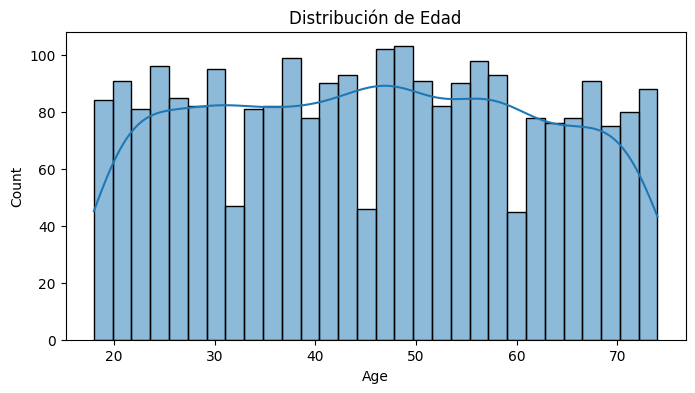

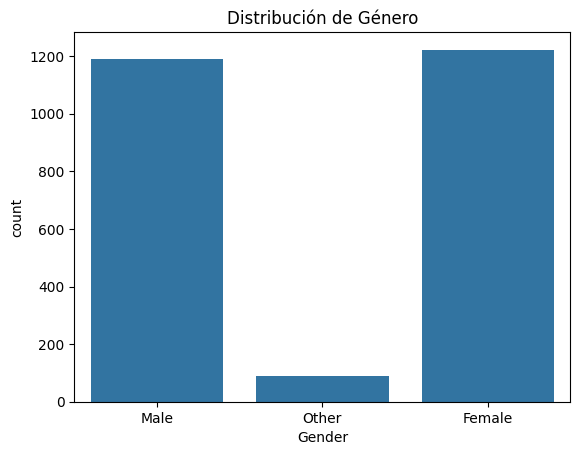

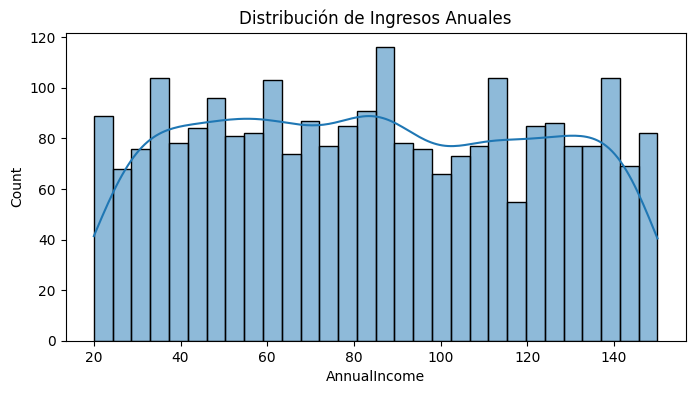

In [2]:
# Análisis Exploratorio de Datos (EDA)
# Inspección inicial
print(df.info())
print(df.describe(include='all'))

# Visualización de distribuciones
plt.figure(figsize=(8,4))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Distribución de Edad')
plt.show()

sns.countplot(x='Gender', data=df)
plt.title('Distribución de Género')
plt.show()

plt.figure(figsize=(8,4))
sns.histplot(df['AnnualIncome'], bins=30, kde=True)
plt.title('Distribución de Ingresos Anuales')
plt.show()

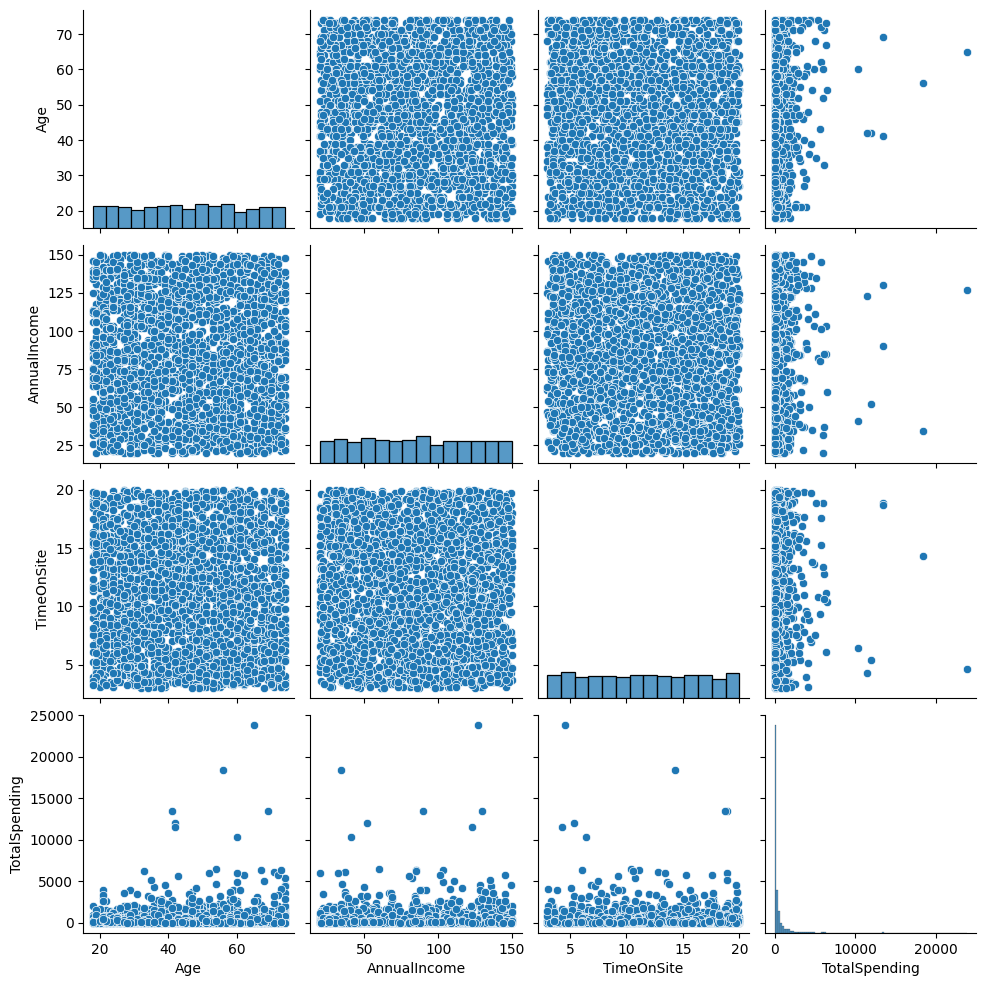

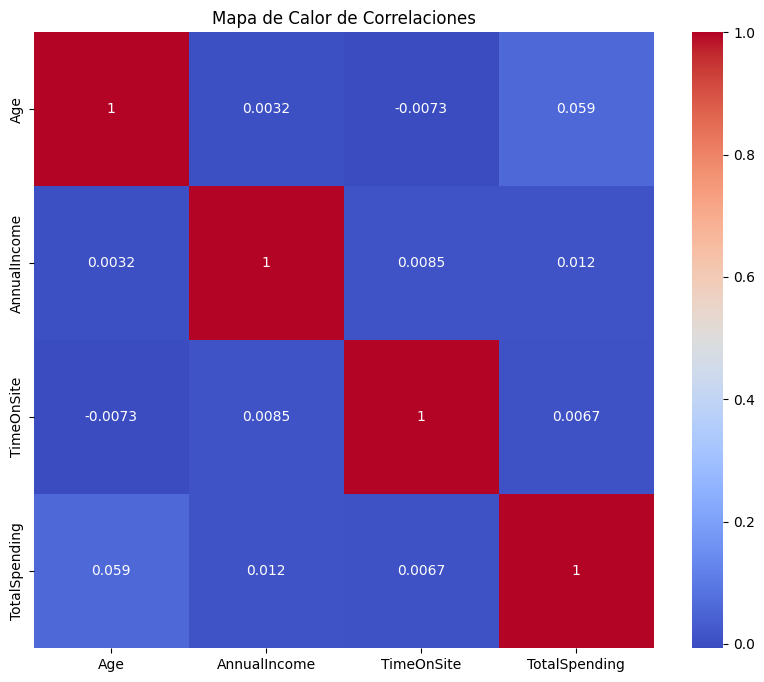

In [3]:
# Visualización de Relaciones Clave
sns.pairplot(df[['Age', 'AnnualIncome', 'TimeOnSite', 'TotalSpending']])
plt.show()

# Heatmap de correlación
plt.figure(figsize=(10,8))
sns.heatmap(df[['Age', 'AnnualIncome', 'TimeOnSite', 'TotalSpending']].corr(), annot=True, cmap='coolwarm')
plt.title('Mapa de Calor de Correlaciones')
plt.show()

In [4]:
# Modelos Predictivos
# Preparación de datos para regresión
features = ['Age', 'AnnualIncome', 'TimeOnSite', 'ItemsInCart']
X = df[features]
y = df['TotalSpending']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenamiento del modelo Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Evaluación del modelo
y_pred = rf.predict(X_test)
rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f'RMSE del modelo: {rmse:.2f}')

TypeError: got an unexpected keyword argument 'squared'

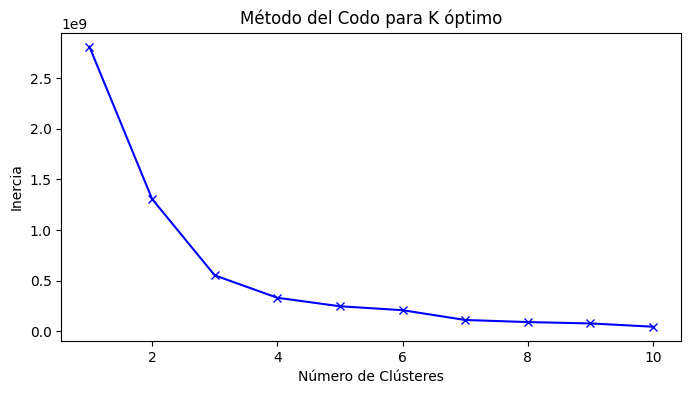

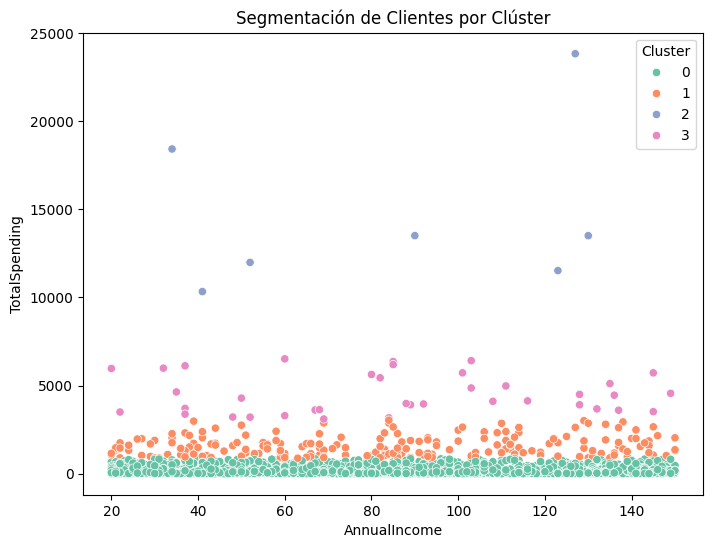

In [5]:
# Segmentación de Clientes
# Preparación de datos para clustering
X_cluster = df[['AnnualIncome', 'TotalSpending']]

# Método del codo para encontrar el número óptimo de clusters
inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_cluster)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,4))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Número de Clústeres')
plt.ylabel('Inercia')
plt.title('Método del Codo para K óptimo')
plt.show()

# Aplicación de K-Means con k óptimo
k_opt = 4
kmeans = KMeans(n_clusters=k_opt, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_cluster)

# Visualización de los clústeres
plt.figure(figsize=(8,6))
sns.scatterplot(x='AnnualIncome', y='TotalSpending', hue='Cluster', data=df, palette='Set2')
plt.title('Segmentación de Clientes por Clúster')
plt.show()

/home/codespace/.python/current/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/home/codespace/.python/current/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/home/codespace/.python/current/lib/python3.12/site-packages/statsmodels/tsa/statespace/mlemodel.py:1235: RuntimeWarning: invalid value encountered in divide
  np.inner(score_obs, score_obs) /


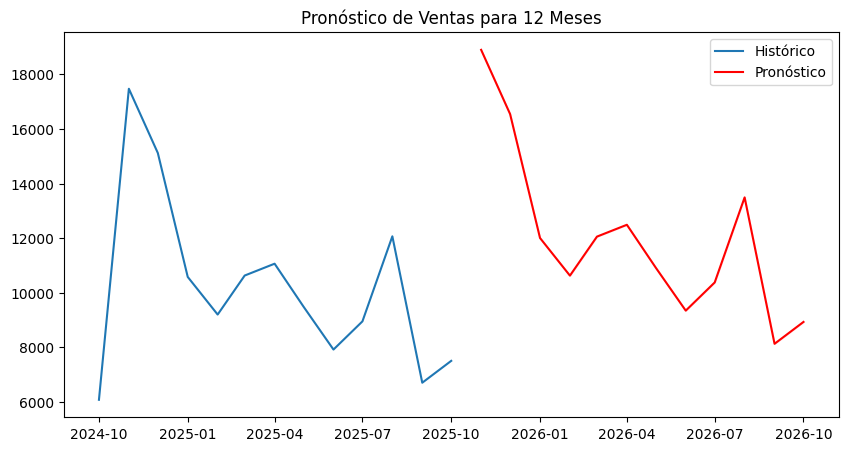

In [6]:
# Pronóstico de Tendencias
# Preparación de la serie temporal
df['Month'] = df['LastPurchaseDate'].dt.to_period('M')
monthly_sales = df.groupby('Month')['LastPurchaseAmount'].sum()
monthly_sales.index = monthly_sales.index.to_timestamp()

# Modelo SARIMA para pronóstico
model = SARIMAX(monthly_sales, order=(1,1,1), seasonal_order=(1,1,1,12))
sarima_fit = model.fit(disp=False)

# Pronóstico de los próximos 12 meses
forecast = sarima_fit.get_forecast(steps=12)
pred = forecast.predicted_mean
conf_int = forecast.conf_int()

# Visualización del pronóstico
plt.figure(figsize=(10,5))
plt.plot(monthly_sales, label='Histórico')
plt.plot(pred, label='Pronóstico', color='red')
plt.fill_between(pred.index, conf_int.iloc[:,0], conf_int.iloc[:,1], color='pink', alpha=0.3)
plt.title('Pronóstico de Ventas para 12 Meses')
plt.legend()
plt.show()

# Conclusiones y Recomendaciones
Tras el análisis de los datos, se destacan los siguientes hallazgos clave:

1. **Segmentación de Clientes**: Se identificaron 4 clústeres principales, con características distintas en términos de ingresos y gasto.
2. **Modelos Predictivos**: El modelo Random Forest predice el gasto total con un RMSE aceptable, destacando la importancia de las variables de ingresos y tiempo en el sitio.
3. **Pronóstico de Ventas**: El modelo SARIMA proyecta un crecimiento estable en las ventas para los próximos 12 meses.

**Recomendaciones Estratégicas:**
- Diseñar campañas específicas para los clústeres de clientes con alto potencial de conversión.
- Optimizar las estrategias de marketing basadas en las predicciones del modelo de clasificación.
- Planificar el inventario y las operaciones logísticas considerando las proyecciones de ventas futuras.